In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/final_emotion_engagement.csv"
)

print(df.shape)

(110336, 16)


In [2]:
emotion_counts = df["Top_Emotion"].value_counts()

emotion_counts

Top_Emotion
neutral     71585
joy         12575
surprise     8848
sadness      6571
anger        4033
fear         3826
disgust      2898
Name: count, dtype: int64

In [3]:
emotion_percentage = (
    df["Top_Emotion"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

emotion_percentage

Top_Emotion
neutral     64.88
joy         11.40
surprise     8.02
sadness      5.96
anger        3.66
fear         3.47
disgust      2.63
Name: proportion, dtype: float64

In [5]:
emotion_cols = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
]

entry_emotions = (
    df.groupby("entry_id")[emotion_cols]
    .mean()
    .reset_index()
)

print("Shape:", entry_emotions.shape)

entry_emotions.head()

Shape: (91071, 8)


,entry_id,anger,disgust,fear,joy,neutral,sadness,surprise
0,e/0000b70d9f3b1d0a7e78bc2ce09af1a2,0.007657,0.000702,0.001875,0.078348,0.238479,0.023530,0.649409
1,e/0000d26daa876fa3165f8808656a30d9,0.302569,0.040035,0.005059,0.006527,0.595786,0.025076,0.024948
2,e/00025446898d8328d8272cce96072696,0.022566,0.023315,0.017705,0.004337,0.750684,0.024067,0.157326
3,e/0004a4a67a3446d79be082181f50c01b,0.005186,0.002103,0.002399,0.008541,0.790450,0.027148,0.164172
4,e/0006970b646d4530991c745db20055b8,0.008938,0.032281,0.002854,0.004950,0.922660,0.016504,0.011814


In [6]:
entry_engagement = (
    df[
        [
            "entry_id",
            "CommentCount",
            "like_count"
        ]
    ]
    .drop_duplicates(
        subset="entry_id"
    )
)

print("Shape:", entry_engagement.shape)

entry_engagement.head()

Shape: (91071, 3)


,entry_id,CommentCount,like_count
0,e/624ca9226b6526ebdb69f9b46df482c7,1,0
1,e/967b4db48fa74021b24ccbc93c55a61c,1,0
2,e/79e585effdf640e988539e2dd68c2c6d,1,0
3,e/01e9a149fff85ff948972896145d3d65,2,0
5,e/77e883844ecc83ea95670032e700f13b,1,0


In [7]:
entry_df = entry_emotions.merge(
    entry_engagement,
    on="entry_id",
    how="left"
)

print("Entry-level shape:", entry_df.shape)

entry_df.head()

Entry-level shape: (91071, 10)


,entry_id,anger,disgust,fear,joy,neutral,sadness,surprise,CommentCount,like_count
0,e/0000b70d9f3b1d0a7e78bc2ce09af1a2,0.007657,0.000702,0.001875,0.078348,0.238479,0.023530,0.649409,1,0
1,e/0000d26daa876fa3165f8808656a30d9,0.302569,0.040035,0.005059,0.006527,0.595786,0.025076,0.024948,1,0
2,e/00025446898d8328d8272cce96072696,0.022566,0.023315,0.017705,0.004337,0.750684,0.024067,0.157326,1,0
3,e/0004a4a67a3446d79be082181f50c01b,0.005186,0.002103,0.002399,0.008541,0.790450,0.027148,0.164172,1,0
4,e/0006970b646d4530991c745db20055b8,0.008938,0.032281,0.002854,0.004950,0.922660,0.016504,0.011814,1,1


In [8]:
print(
    "Unique entry IDs:",
    entry_df["entry_id"].nunique()
)

print(
    "Total rows:",
    len(entry_df)
)

print(
    "Duplicate entry IDs:",
    entry_df["entry_id"].duplicated().sum()
)

Unique entry IDs: 91071
Total rows: 91071
Duplicate entry IDs: 0


In [9]:
correlation_cols = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise",
    "like_count",
    "CommentCount"
]

correlation_matrix = (
    entry_df[correlation_cols]
    .corr(method="spearman")
)

correlation_matrix[
    ["like_count", "CommentCount"]
].round(3)

,like_count,CommentCount
anger,0.115,0.138
disgust,0.155,0.180
fear,0.063,0.088
joy,0.037,0.072
neutral,-0.054,-0.075
sadness,0.090,0.104
surprise,0.015,0.063
like_count,1.000,0.531
CommentCount,0.531,1.000


In [ ]:
from scipy.stats import spearmanr

results = []

for emotion in emotion_cols:

    like_r, like_p = spearmanr(
        entry_df[emotion],
        entry_df["like_count"]
    )

    comment_r, comment_p = spearmanr(
        entry_df[emotion],
        entry_df["CommentCount"]
    )

    results.append({
        "emotion": emotion,
        "like_r": like_r,
        "like_p": like_p,
        "comment_r": comment_r,
        "comment_p": comment_p
    })

correlation_results = pd.DataFrame(results)

correlation_results.round(4)

In [10]:
from scipy.stats import spearmanr

results = []

for emotion in emotion_cols:

    like_r, like_p = spearmanr(
        entry_df[emotion],
        entry_df["like_count"]
    )

    comment_r, comment_p = spearmanr(
        entry_df[emotion],
        entry_df["CommentCount"]
    )

    results.append({
        "emotion": emotion,
        "like_r": like_r,
        "like_p": like_p,
        "comment_r": comment_r,
        "comment_p": comment_p
    })

correlation_results = pd.DataFrame(results)

correlation_results.round(4)

,emotion,like_r,like_p,comment_r,comment_p
0,anger,0.1150,0.0,0.1376,0.0
1,disgust,0.1547,0.0,0.1803,0.0
2,fear,0.0630,0.0,0.0876,0.0
3,joy,0.0366,0.0,0.0725,0.0
4,neutral,-0.0545,0.0,-0.0753,0.0
5,sadness,0.0899,0.0,0.1037,0.0
6,surprise,0.0154,0.0,0.0633,0.0


In [11]:
correlation_results["like_p"] = correlation_results["like_p"].apply(
    lambda x: f"{x:.2e}"
)

correlation_results["comment_p"] = correlation_results["comment_p"].apply(
    lambda x: f"{x:.2e}"
)

correlation_results

,emotion,like_r,like_p,comment_r,comment_p
0,anger,0.115024,9.46e-266,0.137616,0.00e+00
1,disgust,0.154662,0.00e+00,0.180311,0.00e+00
2,fear,0.063018,8.56e-81,0.087642,9.86e-155
3,joy,0.036602,2.21e-28,0.072475,2.60e-106
4,neutral,-0.054465,8.59e-61,-0.075306,1.20e-114
5,sadness,0.089889,1.08e-162,0.103658,5.91e-216
6,surprise,0.015446,3.14e-06,0.063329,1.41e-81


In [12]:
entry_df[
    ["like_count", "CommentCount"]
].describe(
    percentiles=[0.90, 0.95, 0.99]
)

,like_count,CommentCount
count,91071.000000,91071.000000
mean,0.196023,1.211538
std,3.104492,5.023452
min,0.000000,1.000000
90%,0.000000,1.000000
95%,1.000000,1.000000
99%,3.000000,5.000000
max,404.000000,1075.000000


In [13]:
zero_like_percentage = (
    (entry_df["like_count"] == 0)
    .mean()
    * 100
)

print(
    "Entries with zero likes:",
    round(zero_like_percentage, 2),
    "%"
)

Entries with zero likes: 93.03 %


In [14]:
one_comment_percentage = (
    (entry_df["CommentCount"] == 1)
    .mean()
    * 100
)

print(
    "Entries with exactly one comment:",
    round(one_comment_percentage, 2),
    "%"
)

Entries with exactly one comment: 95.76 %


In [15]:
entry_df[
    ["like_count", "CommentCount"]
].describe(
    percentiles=[0.90, 0.95, 0.99]
)

,like_count,CommentCount
count,91071.000000,91071.000000
mean,0.196023,1.211538
std,3.104492,5.023452
min,0.000000,1.000000
90%,0.000000,1.000000
95%,1.000000,1.000000
99%,3.000000,5.000000
max,404.000000,1075.000000


In [16]:
entry_df["has_like"] = (
    entry_df["like_count"] > 0
).astype(int)

entry_df["has_multiple_comments"] = (
    entry_df["CommentCount"] > 1
).astype(int)

In [17]:
print(
    entry_df["has_like"].value_counts()
)

print()

print(
    entry_df["has_multiple_comments"].value_counts()
)

has_like
0    84722
1     6349
Name: count, dtype: int64

has_multiple_comments
0    87206
1     3865
Name: count, dtype: int64


In [18]:
print(
    entry_df["has_like"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print()

print(
    entry_df["has_multiple_comments"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

has_like
0    93.03
1     6.97
Name: proportion, dtype: float64

has_multiple_comments
0    95.76
1     4.24
Name: proportion, dtype: float64


In [19]:
emotion_by_like = (
    entry_df
    .groupby("has_like")[emotion_cols]
    .mean()
    .T
)

emotion_by_like.columns = [
    "No Like",
    "Has Like"
]

emotion_by_like.round(4)

,No Like,Has Like
anger,0.0449,0.0615
disgust,0.0304,0.0503
fear,0.0446,0.0375
joy,0.1193,0.1435
neutral,0.5669,0.4969
sadness,0.0702,0.0705
surprise,0.1236,0.1398


In [20]:
emotion_by_like["difference"] = (
    emotion_by_like["Has Like"]
    - emotion_by_like["No Like"]
)

emotion_by_like.sort_values(
    "difference",
    ascending=False
).round(4)

,No Like,Has Like,difference
joy,0.1193,0.1435,0.0241
disgust,0.0304,0.0503,0.0200
anger,0.0449,0.0615,0.0165
surprise,0.1236,0.1398,0.0162
sadness,0.0702,0.0705,0.0003
fear,0.0446,0.0375,-0.0071
neutral,0.5669,0.4969,-0.0701


In [21]:
emotion_by_comments = (
    entry_df
    .groupby("has_multiple_comments")[emotion_cols]
    .mean()
    .T
)

emotion_by_comments.columns = [
    "One Comment",
    "Multiple Comments"
]

emotion_by_comments.round(4)

,One Comment,Multiple Comments
anger,0.0453,0.0650
disgust,0.0304,0.0630
fear,0.0444,0.0375
joy,0.1202,0.1390
neutral,0.5662,0.4693
sadness,0.0700,0.0767
surprise,0.1236,0.1495


In [22]:
emotion_by_comments["difference"] = (
    emotion_by_comments["Multiple Comments"]
    - emotion_by_comments["One Comment"]
)

emotion_by_comments.sort_values(
    "difference",
    ascending=False
).round(4)

,One Comment,Multiple Comments,difference
disgust,0.0304,0.0630,0.0326
surprise,0.1236,0.1495,0.0259
anger,0.0453,0.0650,0.0197
joy,0.1202,0.1390,0.0188
sadness,0.0700,0.0767,0.0068
fear,0.0444,0.0375,-0.0069
neutral,0.5662,0.4693,-0.0968


In [23]:
from scipy.stats import mannwhitneyu

like_test_results = []

for emotion in emotion_cols:

    no_like = entry_df.loc[
        entry_df["has_like"] == 0,
        emotion
    ]

    has_like = entry_df.loc[
        entry_df["has_like"] == 1,
        emotion
    ]

    stat, p = mannwhitneyu(
        no_like,
        has_like,
        alternative="two-sided"
    )

    like_test_results.append({
        "emotion": emotion,
        "U_statistic": stat,
        "p_value": p
    })

like_test_df = pd.DataFrame(like_test_results)

like_test_df

,emotion,U_statistic,p_value
0,anger,198875033.0,1.445264e-263
1,disgust,175027314.5,0.000000e+00
2,fear,230592088.0,2.284350e-80
3,joy,246485371.0,1.019518e-28
4,neutral,302576911.0,3.394108e-62
5,sadness,214347116.0,7.545357e-161
6,surprise,259289678.5,1.742327e-06


In [24]:
like_test_df["p_value"] = (
    like_test_df["p_value"]
    .apply(lambda x: f"{x:.3e}")
)

like_test_df

,emotion,U_statistic,p_value
0,anger,198875033.0,1.445e-263
1,disgust,175027314.5,0.000e+00
2,fear,230592088.0,2.284e-80
3,joy,246485371.0,1.020e-28
4,neutral,302576911.0,3.394e-62
5,sadness,214347116.0,7.545e-161
6,surprise,259289678.5,1.742e-06


In [25]:
effect_results = []

n0 = (entry_df["has_like"] == 0).sum()
n1 = (entry_df["has_like"] == 1).sum()

for emotion in emotion_cols:

    no_like = entry_df.loc[
        entry_df["has_like"] == 0,
        emotion
    ]

    has_like = entry_df.loc[
        entry_df["has_like"] == 1,
        emotion
    ]

    U, p = mannwhitneyu(
        has_like,
        no_like,
        alternative="two-sided"
    )

    rbc = (2 * U) / (n1 * n0) - 1

    effect_results.append({
        "emotion": emotion,
        "effect_size": rbc,
        "abs_effect": abs(rbc)
    })

effect_df = pd.DataFrame(effect_results)

effect_df.sort_values(
    "abs_effect",
    ascending=False
).round(4)

,emotion,effect_size,abs_effect
1,disgust,0.3492,0.3492
0,anger,0.2606,0.2606
5,sadness,0.2030,0.2030
2,fear,0.1426,0.1426
4,neutral,-0.1250,0.1250
3,joy,0.0835,0.0835
6,surprise,0.0359,0.0359


In [26]:
comment_effect_results = []

n0 = (entry_df["has_multiple_comments"] == 0).sum()
n1 = (entry_df["has_multiple_comments"] == 1).sum()

for emotion in emotion_cols:

    one_comment = entry_df.loc[
        entry_df["has_multiple_comments"] == 0,
        emotion
    ]

    multiple_comments = entry_df.loc[
        entry_df["has_multiple_comments"] == 1,
        emotion
    ]

    U, p = mannwhitneyu(
        multiple_comments,
        one_comment,
        alternative="two-sided"
    )

    rbc = (2 * U) / (n1 * n0) - 1

    comment_effect_results.append({
        "emotion": emotion,
        "effect_size": rbc,
        "abs_effect": abs(rbc),
        "p_value": p
    })

comment_effect_df = pd.DataFrame(comment_effect_results)

comment_effect_df.sort_values(
    "abs_effect",
    ascending=False
).round(4)

,emotion,effect_size,abs_effect,p_value
1,disgust,0.5129,0.5129,0.0
0,anger,0.3911,0.3911,0.0
5,sadness,0.2943,0.2943,0.0
2,fear,0.2487,0.2487,0.0
4,neutral,-0.2146,0.2146,0.0
3,joy,0.2055,0.2055,0.0
6,surprise,0.1793,0.1793,0.0


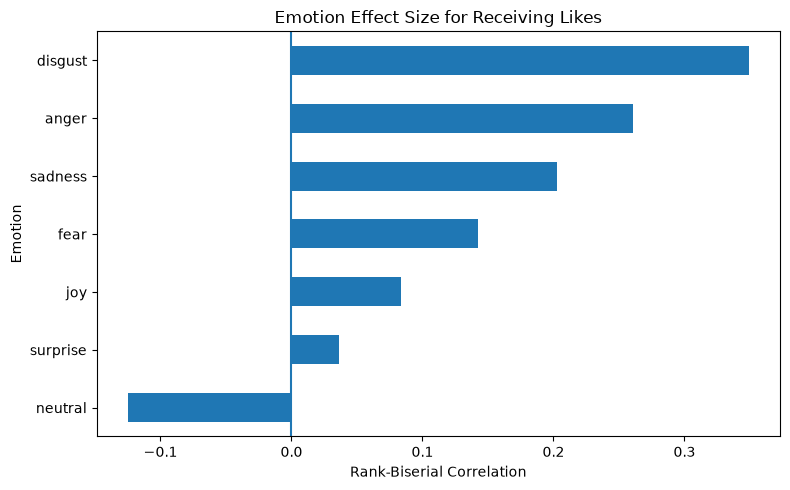

In [27]:
effect_df.sort_values(
    "effect_size"
).plot(
    x="emotion",
    y="effect_size",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)

plt.axvline(0)
plt.title("Emotion Effect Size for Receiving Likes")
plt.xlabel("Rank-Biserial Correlation")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

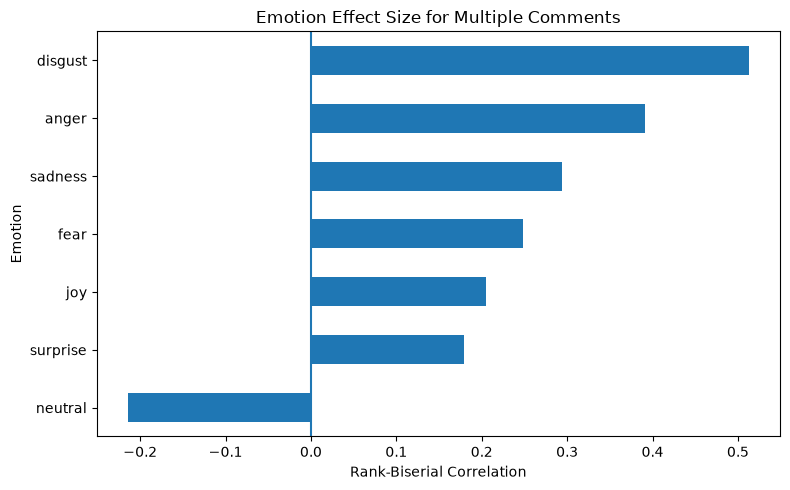

In [28]:
comment_effect_df.sort_values(
    "effect_size"
).plot(
    x="emotion",
    y="effect_size",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)

plt.axvline(0)
plt.title("Emotion Effect Size for Multiple Comments")
plt.xlabel("Rank-Biserial Correlation")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

In [29]:
entry_df.to_csv(
    "../data/processed/entry_level_emotion_engagement.csv",
    index=False
)

print("Saved:", entry_df.shape)

Saved: (91071, 12)
